# Car Price Prediction using Machine Learning

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading and Initial Exploration

In [94]:
df = pd.read_csv("Automobile_data.csv")

In [95]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [96]:
df.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,10.142537,25.219512,30.751220
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,3.972040,6.542142,6.886443
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,8.600000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,9.400000,30.000000,34.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000


In [97]:
df.replace('?',np.nan,inplace=True)

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       203 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

## 2. Data Cleaning and Missing Value Handling

In [99]:
median_cols = ['normalized-losses', 'bore', 'stroke','horsepower', 'peak-rpm','price']

for col in median_cols:
  df[col] = pd.to_numeric(df[col],errors='coerce')
  df[col] = df[col].fillna(df[col].median())


In [100]:
df['num-of-doors'] = df['num-of-doors'].fillna(df['num-of-doors'].mode()[0])

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    float64
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [102]:
df['price'] = pd.to_numeric(df['price'],
errors='coerce')

In [103]:
df.head()




,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,115.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


<Axes: xlabel='peak-rpm'>

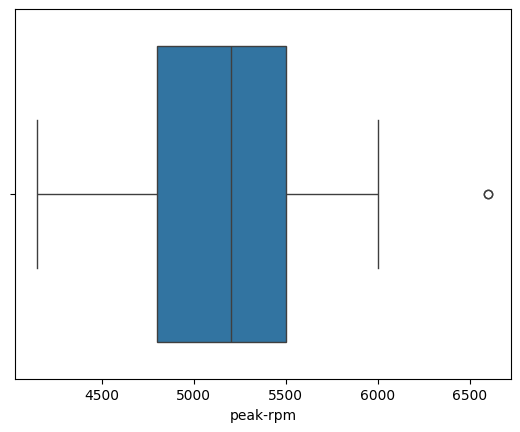

In [104]:
sns.boxplot(x=df['peak-rpm'])


<Axes: xlabel='bore'>

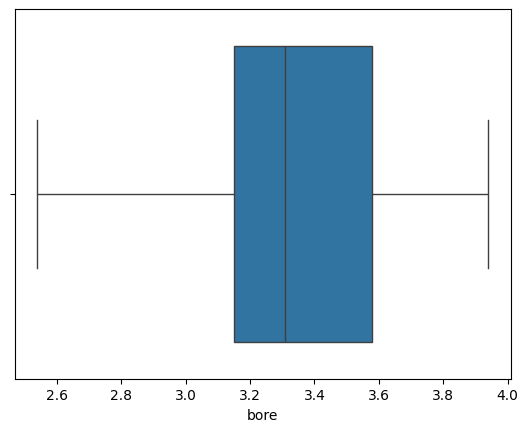

In [105]:
sns.boxplot(x=df['bore'],)

<Axes: xlabel='stroke'>

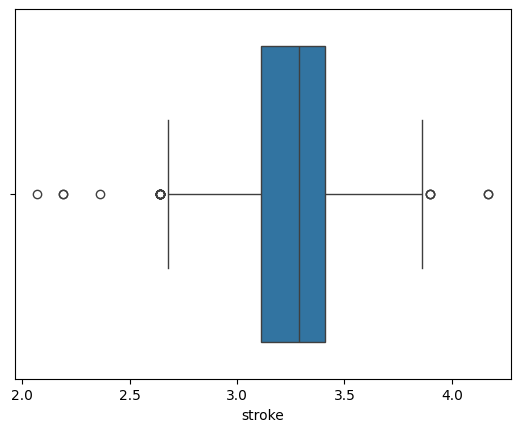

In [106]:
sns.boxplot(x=df['stroke'])

<Axes: xlabel='horsepower'>

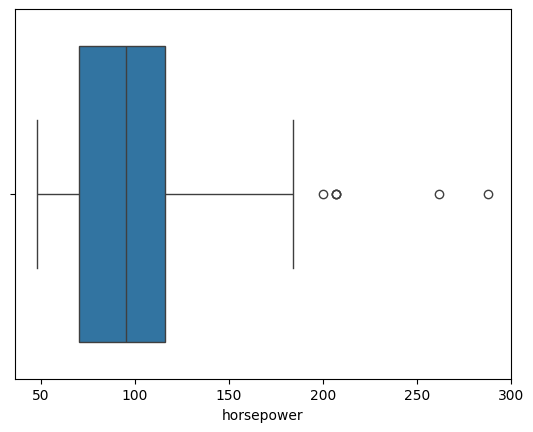

In [107]:
sns.boxplot(x=df['horsepower'])

<Axes: xlabel='price'>

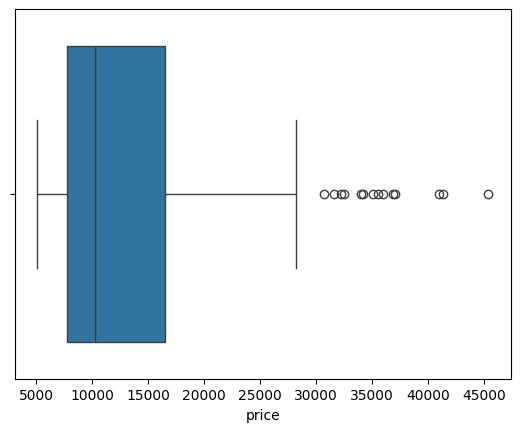

In [108]:
sns.boxplot(x=df['price'])

In [109]:
cols = ['stroke', 'horsepower', 'price']
for col in cols:
  df[col] = pd.to_numeric(df[col],errors='coerce')

In [110]:
outliers = ['stroke', 'horsepower', 'price']
for columns in outliers:

  Q1 = df[columns].quantile(0.25)
  Q3 = df[columns].quantile(0.75)

  IQR = Q3 - Q1
  lower_bound = Q1 -1.5 *IQR
  upper_bound = Q3 +1.5 *IQR

  df = df[(df[columns] >= lower_bound) & (df[columns] <= upper_bound)]


In [111]:
df.head(2)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0


In [112]:
df['Avg_Mpg'] = (df['city-mpg'] + df['highway-mpg']) / 2
df[['city-mpg', 'highway-mpg', 'Avg_Mpg']].head

<bound method NDFrame.head of      city-mpg  highway-mpg  Avg_Mpg
0          21           27     24.0
1          21           27     24.0
2          19           26     22.5
3          24           30     27.0
4          18           22     20.0
..        ...          ...      ...
200        23           28     25.5
201        19           25     22.0
202        18           23     20.5
203        26           27     26.5
204        19           25     22.0

[171 rows x 3 columns]>

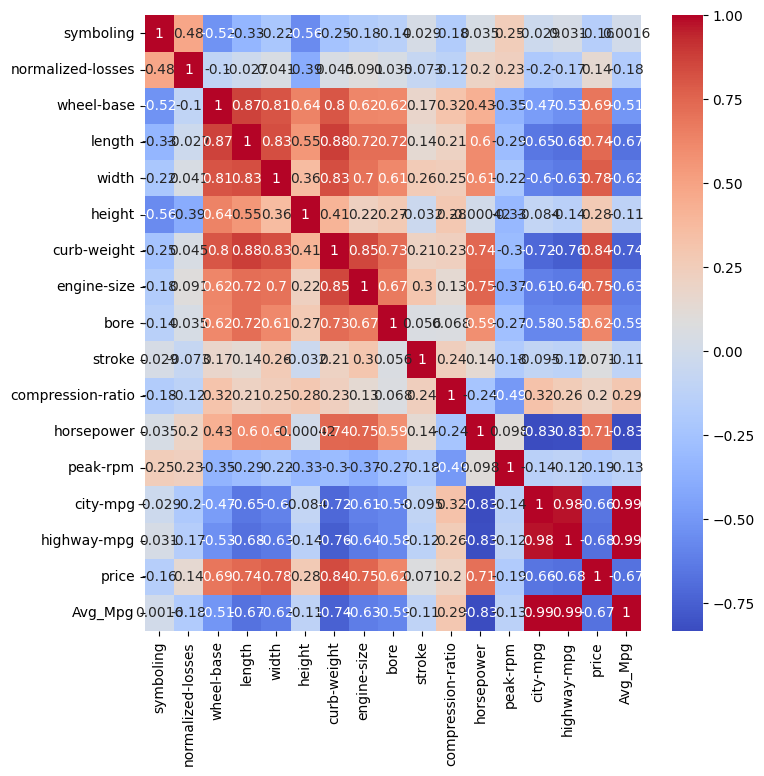

In [113]:


plt.figure(figsize=(8,8))
sns.heatmap(df.corr(numeric_only=True),
annot=True,cmap='coolwarm')
plt.show()


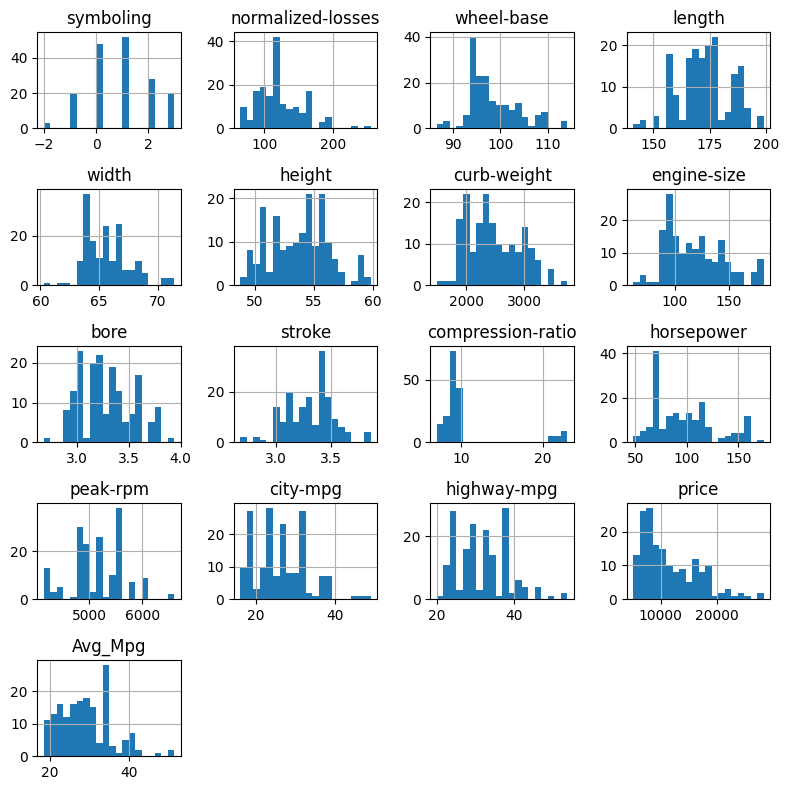

In [114]:
import matplotlib.pyplot as plt
df.hist(figsize=(8,8),bins=20)
plt.tight_layout()
plt.show()

In [115]:
X = df.drop('price',axis=1)
y = df['price']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (171, 26)
Target shape: (171,)


In [116]:
from sklearn.model_selection import train_test_split


X_train , X_test , y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

print("Training data: ", X_train.shape)
print("Testing data:", X_test.shape)

Training data:  (136, 26)
Testing data: (35, 26)


In [117]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_cols = X_train.select_dtypes(include=['object']).columns
numeric_cols = X_train.select_dtypes(exclude=['object']).columns

print("Categorical columns:")
print(list(categorical_cols))

print("\nNumeric columns:")
print(list(numeric_cols))

Categorical columns:
['make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders', 'fuel-system']

Numeric columns:
['symboling', 'normalized-losses', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-size', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'Avg_Mpg']


In [118]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'),categorical_cols)
    ]
)

In [119]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ("preprosser", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("Linear Regression model trained succesfully")


Linear Regression model trained succesfully


In [120]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test , y_pred_linear)

print("Linear Regression Results")
print("____________________")
print("MAE", mae_linear)
print("MSE", mse_linear)
print("RMSE", rmse_linear)
print("R2", r2_linear)

Linear Regression Results
____________________
MAE 1745.928461482936
MSE 6300161.204852383
RMSE 2510.0121921720583
R2 0.7368026912971077


In [121]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(
    steps=[
        ("prepocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42
        ))
    ]
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Rarndom Forest Reggression model traind successfully")

Rarndom Forest Reggression model traind successfully


In [122]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression Results")
print("---------------------------------")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Regression Results
---------------------------------
MAE : 1153.1854727891157
MSE : 2962425.2927119676
RMSE: 1721.1697454672992
R²  : 0.8762408867134001


In [123]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42


        ))
    ]
)

gb_model.fit(X_train,y_train)

y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Regression model trained successfully")



Gradient Boosting Regression model trained successfully


In [124]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Regression Results")
print("__________________________________")
print("MAE:", mae_gb)
print("MSE:", mse_gb)
print("RMSE:", rmse_gb)
print("R2", r2_gb)

Gradient Boosting Regression Results
__________________________________
MAE: 1239.0999553033964
MSE: 3891948.408697189
RMSE: 1972.8021717083518
R2 0.8374088672539601


In [125]:
results = pd.DataFrame({
    'Model' : [
        'Linear Regression',
        'Random Forest Regression',
        'Gradient Boosting Regression'

    ],

    'MAE' : [
        mae_linear,
        mae_rf,
        mae_gb
    ],
    'MSE': [
        mse_linear,
        mse_rf,
        mse_gb
    ],
    'RMSE' : [
        rmse_linear,
        rmse_rf,
        rmse_gb
    ],

    'R2' : [
        r2_linear,
        r2_rf,
        r2_gb
    ],
})



In [126]:
results = results.sort_values(by='R2', ascending=False).reset_index(drop=True)

results

,Model,MAE,MSE,RMSE,R2
0,Random Forest Regression,1153.185473,2.962425e+06,1721.169745,0.876241
1,Gradient Boosting Regression,1239.099955,3.891948e+06,1972.802172,0.837409
2,Linear Regression,1745.928461,6.300161e+06,2510.012192,0.736803


In [127]:
best_model_name = results.loc[results['R2'].idxmax(),'Model']

print("Best Model: ", best_model_name)


Best Model:  Random Forest Regression


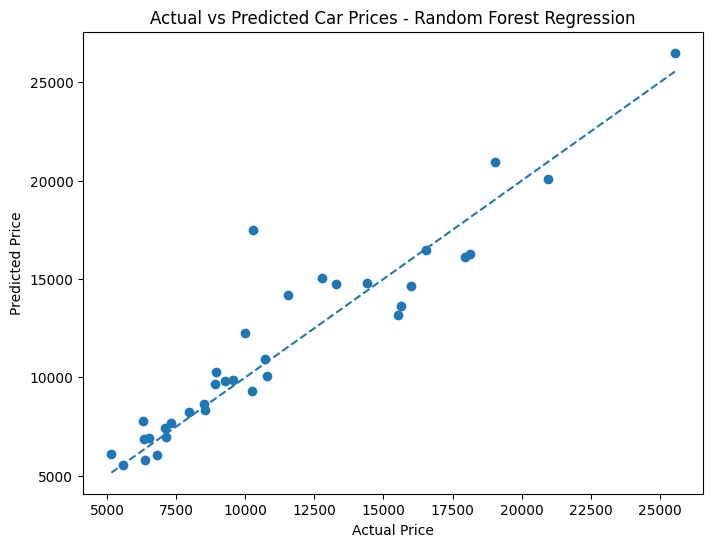

In [128]:
if best_model_name == 'Linear Regression':
  best_predictions = y_pred_linear

elif best_model_name == 'Random Forest Regression':
  best_predictions = y_pred_rf

else:
  best_predictions = y_pred_gb

plt.figure(figsize=(8,6))

plt.scatter(y_test, best_predictions)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted Car Prices - {best_model_name}")

plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    linestyle='--'
)
plt.show()

In [129]:
prediction_comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': best_predictions
})

prediction_comparison['Difference'] = (prediction_comparison['Actual Price'] - prediction_comparison['Predicted Price'])

prediction_comparison.head()

,Actual Price,Predicted Price,Difference
0,17950.0,16138.795000,1811.205000
1,10245.0,9299.437619,945.562381
2,10795.0,10053.862619,741.137381
3,8948.0,10291.668333,-1343.668333
4,13295.0,14735.360833,-1440.360833


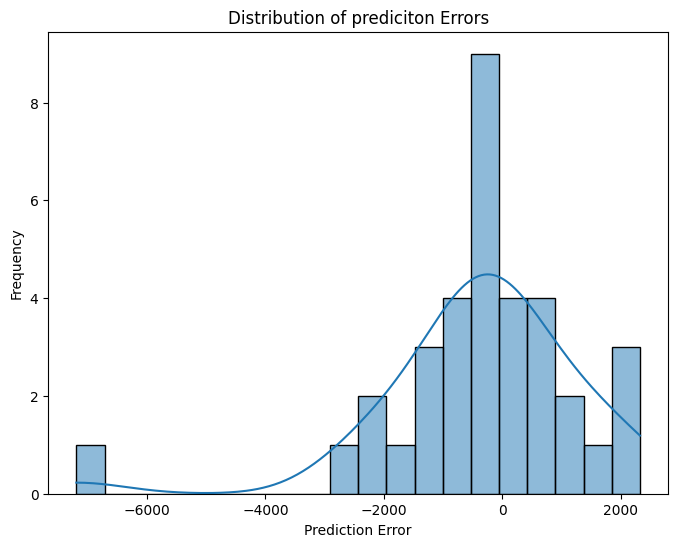

In [130]:
errors = y_test - best_predictions

plt.figure(figsize=(8,6))

sns.histplot(errors, bins=20, kde=True)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of prediciton Errors")

plt.show()

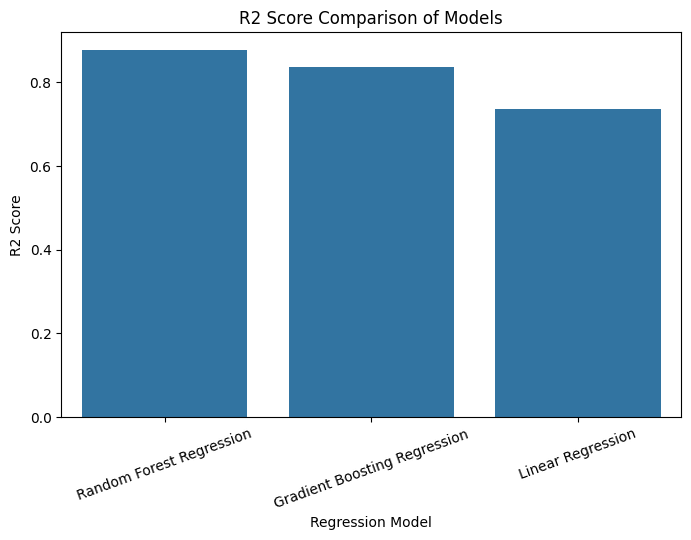

In [131]:
plt.figure(figsize=(8,5))

sns.barplot(data=results,x='Model', y='R2')

plt.xticks(rotation=20)
plt.title("R2 Score Comparison of Models")
plt.ylabel("R2 Score")
plt.xlabel("Regression Model")

plt.show()

## Conclusion

In this project, a car price prediction model was developed using the Automobile dataset.

The project involved data cleaning, missing-value handling, exploratory data analysis, feature preprocessing, categorical encoding, train-test splitting, and regression model development.

Three regression algorithms were evaluated:
1. Linear Regression
2. Random Forest Regression
3. Gradient Boosting Regression

The models were evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

Based on the evaluation results, the model with the highest R² Score was selected as the best-performing model.

The final model can be used to estimate car prices based on various vehicle characteristics such as engine size, horsepower, curb weight, fuel type, body style, and other available features.